In [1]:
from pyhermes.base.convols import Convols
from pyhermes.theory.counting import Counting
from pyhermes.theory.corr2pcf import Corr_2PCF, calc_DD_mean_r
from pyhermes.theory.corr3pcf import Corr_3PCF, calc_DDD_mean_mc
from pyhermes.param.parambase import read_param
from pyhermes.utils import math_util
from pyhermes.io import WindowFunc, ConvolsData, CountingData, Corr2PCFData, Corr3PCFData
import matplotlib.pyplot as plt
import numpy as np

**Conventions**
- All fields ($\epsilon$, $n(x)$) are normalized in GRID space:
    sum over all grid cells = 1
- Uniform random field is constant in GRID space:
    R = $1 / V$,  $V = L^3$
  hence: RR = $R^2$, RRR = $R^3$

Coordinates:
- Physical: x in [0, SimBoxL)   (Mpc/h)
- Scaled (GRID): x_scaled = x_phys * ScaleFactor in [0, L)
  where ScaleFactor = L / SimBoxL

The reduced 3PCF $Q(\theta)$ evaluated by using:
- $\xi(r)$ from convolution-based estimator on GRID
- $\zeta(\theta)$ from Monte Carlo over triangle orientations and random centers (GRID)

## Convols Data

```python
# run_convols.py
convols_params = read_param(config_path='./configs/param_convols.yaml')
convols = Convols(param_task=convols_params)
convols.run(overwrite=True)
```

```yaml
# configs/param_convols.yaml
Convols:
   J: 8
   fin:
      path: "https://pyhermes.astroslacker.com/_downloads/906e0695649e3634a5fe8081b9ab2086/quijote10000.bin"
      format: "generic_pos"
   fout_path: "./output/quijote_sfc.pkl"
   SampRate: 1024
   SimBoxL: 1000
   wavelet_mode: "db2"
   wavelet_level: 10
   bandwidth: 1
```

In [2]:
! mpirun -np 4 python run_convols.py

14:58:03 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_convols.yaml'
14:58:03 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
14:58:03 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
14:58:03 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.J' from '9' to '8'
14:58:03 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.fin.path' from './data.bin' to 'https://pyhermes.astroslacker.com/_downloads/906e0695649e3634a5fe8081b9ab2086/quijote10000.bin'
14:58:03 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.fout_path' from 'empty' to './output/quijote_sfc.pkl'

14:58:03 - INFO - pyhermes.pipeline.pipeline:Convols - The task will run on 4 MPI ranks with 1 threads per rank
14:58:03 - INFO - pyhermes.io.funcs:read_particle_data - Selected input particle format: generic_pos
14:58:04 - INFO - pyhermes.io.funcs:dl_rich_pbar - File 'quijote10000

In [3]:
# read convols
D = ConvolsData(data_path='./output/quijote_sfc.pkl')
R = 1 / D.V

14:58:09 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote_sfc.pkl <---
14:58:09 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.399e-06, Max = 1.305e-05, Mean = 5.96e-08, Sum = 1


**setup filter**:

In [4]:
win_params = {"type": "sphere", "len_args": {"R": 20}}
filter_sph20 = WindowFunc(win_params, D.convols_info)
D_sph20 = D @ filter_sph20

## Counting

```python
# run_counting.py

counting_params = read_param(config_path='./configs/param_counting.yaml')
# counting_params['Counting']['window'] = {}
# counting_params['Counting']['fout_path'] = "./output/quijote_counting.pkl"
counting = Counting(param_task=counting_params)
counting.run(overwrite=True)
```

```yaml
# configs/param_counting.yaml
Counting:
  N_randoms: 10000000
  convols_data_path: "./output/quijote_sfc.pkl" 
  fout_path: "./output/quijote_counting_sph20.pkl"
  window:
    type: sphere
    len_args:
      R: 20
```

In [5]:
! mpirun -np 4 python run_counting.py

14:58:57 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_counting.yaml'
14:58:57 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
14:58:57 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
14:58:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.N_randoms' from '1000000' to '10000000'
14:58:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.convols_data_path' from 'empty' to './output/quijote_sfc.pkl'
14:58:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.fout_path' from 'empty' to './output/quijote_counting_sph20.pkl'
14:58:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.window.type' from 'empty' to 'sphere'
14:58:57 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Counting.window.len_args.R'

14:58:57 - INFO - pyhermes.pipeline.pipeline:Counting - The task will run on 4 MPI ranks

14:59:23 - INFO - pyhermes.io.base:CountingData - Reading Counting data from ---> ./output/quijote_counting_sph20.pkl <---
14:59:24 - INFO - pyhermes.io.base:CountingData - nx: Shape(10000000,), Min = -7.953e-05, Max = 0.002404, Mean = 0.0004068


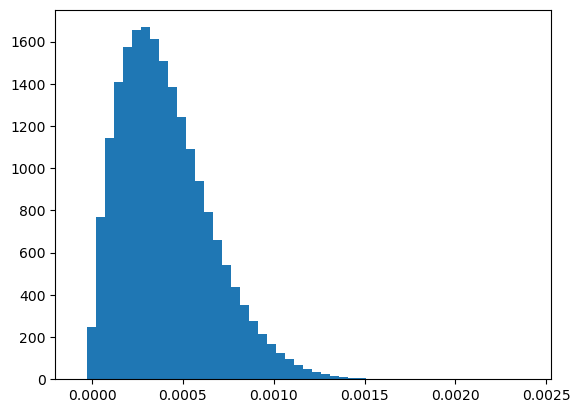

In [6]:
# read counting
counting = CountingData(data_path="./output/quijote_counting_sph20.pkl")
# counting = CountingData(data_path="./output/quijote_counting.pkl")

plt.hist(counting.nx, bins=50, density=True)
plt.show()

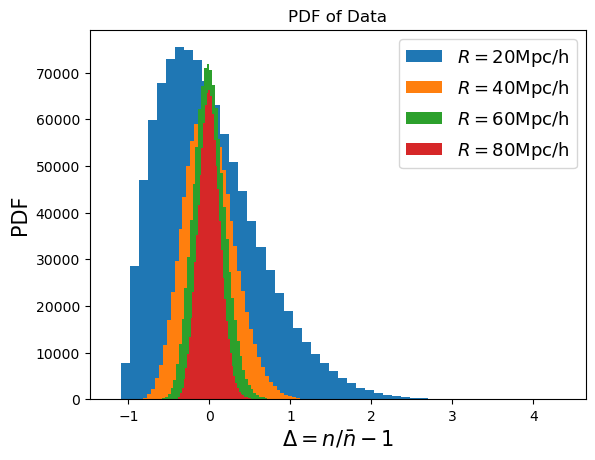

In [7]:
rand = math_util.random_points_box(10**6, D.SimBoxL)
win_params = dict(type="sphere", len_args={})
for smooth_radius in [20, 40, 60, 80]:
    win_params["len_args"]["R"] = smooth_radius
    filter = WindowFunc(win_params, D.convols_info)
    n = D.n_at_pos(rand, filter=filter)
    plt.hist(n/n.mean()-1, bins=50, density=False, label=rf'$R={smooth_radius}$Mpc/h')

plt.title('PDF of Data')
plt.xlabel(r'$\Delta=n/{\bar n}-1$', fontsize=15)
plt.ylabel('PDF', fontsize=15)
plt.legend(fontsize=13)
plt.show()

## 2PCF

```python
# run_2pcf.py
corr2pcf_params = read_param(config_path='./configs/param_2pcf.yaml')
# corr2pcf_params['Corr_2PCF']['n_r'] = 20
# corr2pcf_params['Corr_2PCF']['fout_path'] = "./output/quijote_2pcf_num20.pkl"
corr2pcf = Corr_2PCF(param_task=corr2pcf_params)
corr2pcf.run(overwrite=True)
```

```yaml
# configs/param_2pcf.yaml
Corr_2PCF:
   convols_data_path: "./output/quijote_sfc.pkl" 
   fout_path: "./output/quijote_2pcf.pkl"
   r_min: 1.0
   r_max: 150.0
   n_r: 30
```

In [8]:
! mpirun -np 4 python run_2pcf.py

14:59:39 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf.yaml'
14:59:39 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
14:59:39 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
14:59:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data_path' from 'empty' to './output/quijote_sfc.pkl'
14:59:39 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to './output/quijote_2pcf.pkl'

14:59:39 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - The task will run on 4 MPI ranks with 1 threads per rank
14:59:39 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote_sfc.pkl <---
14:59:39 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.399e-06, Max = 1.305e-05, Mean = 5.96e-08, Sum = 1
14:59:40 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Start to calcu

In [9]:
# read corr2pcf data
corr2pcf_data = Corr2PCFData(data_path='./output/quijote_2pcf.pkl')

14:59:59 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote_2pcf.pkl <---
14:59:59 - INFO - pyhermes.io.base:Corr2PCFData - r: Num = 30, Min = 1, Max = 150
14:59:59 - INFO - pyhermes.io.base:Corr2PCFData - xi: Mean = 1.386, Min = -0.001638, Max = 39.28


In [10]:
deltaD = D - R
deltaD_sph20 = deltaD @ filter_sph20
RR = R ** 2

r_arr = np.linspace(1, 150, 30)
xi_arr = np.zeros_like(r_arr)
for i, r in enumerate(r_arr):
    win_params = {"type": "shell", "len_args": {"R": r}}
    win_shell = WindowFunc(win_params, D.convols_info)

    deltaDD = deltaD_sph20 @ win_shell * deltaD_sph20
    
    xi_arr[i] = deltaDD.as_array().mean() / RR 

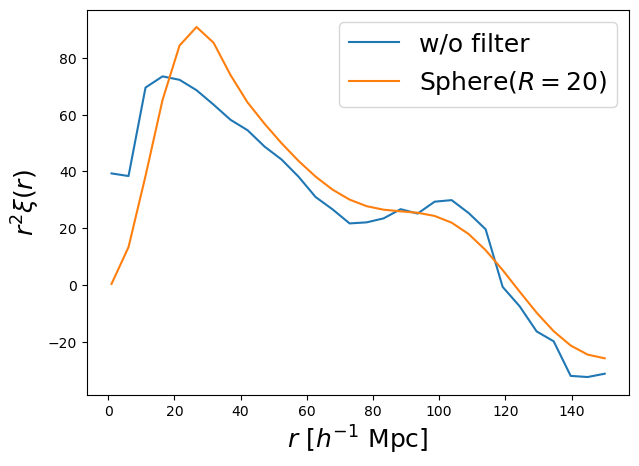

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(corr2pcf_data.r, corr2pcf_data.xi*corr2pcf_data.r**2, label='w/o filter')
plt.plot(r_arr, xi_arr*r_arr**2, label=rf'Sphere($R=20$)')

plt.xlabel(r'$r\ [h^{-1}\ \mathrm{Mpc}]$', fontsize='18')
plt.ylabel(r'$r^2 \xi(r)$', fontsize='18')
plt.legend(loc='best', fontsize='18')
plt.show()

**customize window**

In [12]:
from numba import njit

@njit
def window_function_cosine_numba(ki, kj, kk, R):
    k = np.sqrt(ki**2 + kj**2 + kk**2)
    Phase = 2 * np.pi * k * R
    result = np.cos(Phase)
    return result

In [13]:
win_params = {"type": "gaussian", "len_args": {"R": 8}}
filter_gauss8 = WindowFunc(win_params, D.convols_info)
deltaD_gauss8 = deltaD @ filter_gauss8

xi2_arr = np.zeros_like(r_arr)
for i, r in enumerate(r_arr):
    win_params = {"func": window_function_cosine_numba, "len_args": {"R": r}}
    win_cos = WindowFunc(win_params, D.convols_info)

    deltaDD = deltaD_gauss8 @ win_cos * deltaD_gauss8
    
    xi2_arr[i] = deltaDD.as_array().mean() / RR


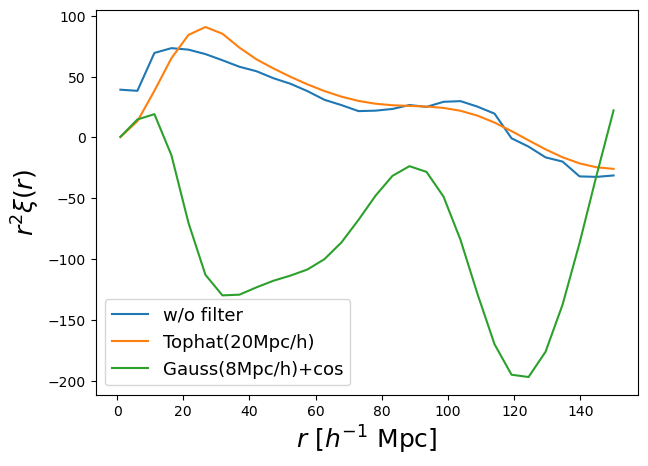

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(corr2pcf_data.r, corr2pcf_data.xi*corr2pcf_data.r**2, label='w/o filter')
plt.plot(r_arr, xi_arr*r_arr**2, label=rf'Tophat(20Mpc/h)')
plt.plot(r_arr, xi2_arr*r_arr**2, label=rf'Gauss(8Mpc/h)+cos')

plt.xlabel(r'$r\ [h^{-1}\ \mathrm{Mpc}]$', fontsize='18')
plt.ylabel(r'$r^2 \xi(r)$', fontsize='18')
plt.legend(loc='best', fontsize='13')
plt.show()

## 3PCF

```python
# run_3pcf.py
corr3pcf_params = read_param(config_path='./configs/param_3pcf.yaml')
# corr3pcf_params['Corr_3PCF']['center'] = 'particle'
# corr3pcf_params['Corr_3PCF']['fout_path'] = "./output/quijote_3pcf_part.pkl"
corr3pcf = Corr_3PCF(param_task=corr3pcf_params)
corr3pcf.run(overwrite=True)
```

```yaml
# configs/param_3pcf.yaml
Corr_3PCF:
   convols_data_path: "./output/quijote_sfc.pkl" 
   fout_path: "./output/quijote_3pcf_rand1e7.pkl"
   window2:
      type: "sphere"
      len_args:
         R: 5
   window3:
      type: "sphere"
      len_args:
         R: 5
   r12: 20.0
   r13: 40.0
   n_theta: 20
   n_rot: 20
   # center: "particle"
   center: "random"
   n_rand: 10000000
   base_seed: 42
```

In [35]:
! mpirun -np 4 python run_3pcf.py

14:42:02 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_3pcf.yaml'
14:42:02 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
14:42:02 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
14:42:02 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.convols_data_path' from 'empty' to './output/quijote_sfc.pkl'
14:42:02 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.fout_path' from 'empty' to './output/quijote_3pcf_part.pkl'
14:42:02 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window2.type' from 'empty' to 'sphere'
14:42:02 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.window2.len_args.R'
14:42:02 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window3.type' from 'empty' to 'sphere'
14:42:02 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF

In [15]:
# read corr3pcf data
corr3pcf_data_part = Corr3PCFData(data_path='./output/quijote_3pcf_part.pkl')
corr3pcf_data_rand = Corr3PCFData(data_path='./output/quijote_3pcf_rand1e7.pkl')

15:01:33 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote_3pcf_part.pkl <---
15:01:33 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote_3pcf_rand1e7.pkl <---


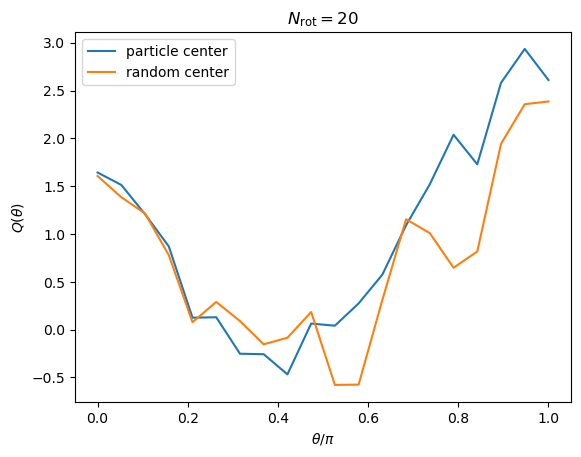

In [16]:
plt.plot(corr3pcf_data_part.theta/np.pi, corr3pcf_data_part.Q, label='particle center')
plt.plot(corr3pcf_data_rand.theta/np.pi, corr3pcf_data_rand.Q, label='random center')
plt.legend()
plt.title(r'$N_{\rm rot}=20$')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta)$")
plt.show()

$n_R=\frac{1}{V};\quad <R>=n_R;\quad <RR> = n^2_R;\quad <RRR> = n^3_R$

$
\xi_{12} =\frac{<D_1D_{W2}>}{<R_1R_2>}-1;\quad 
\xi_{13} =\frac{<D_1D_{W3}>}{<R_1R_3>}-1;\quad
\xi_{23} =\frac{<D_{W2}D_{W3}>}{<R_2R_3>}-1
$

$\zeta^\prime = \frac{<D_1D_{W2}D_{W3}>}{<R_1R_2R_3>}-1$

$\zeta = \frac{<(D_1-R_1)(D_{W2}-R_2)(D_{W3}-R_3)>}{<R_1R_2R_3>} = \zeta^\prime-\xi_{12}-\xi_{13}-\xi_{23}$

$\zeta_{\rm H} = \xi_{12}\xi_{23} + \xi_{13}\xi_{23} + \xi_{12}\xi_{13}$

$Q = \zeta/\zeta_{\rm H}$


In [17]:
D = ConvolsData(data_path="./output/quijote_sfc.pkl")
R = 1.0 / D.V
RR = R ** 2
RRR = R ** 3

filter_sph5 = WindowFunc({"type": "sphere", "len_args": {"R": 5}}, D.convols_info)
D_sph5 = D @ filter_sph5
deltaD = D - R
deltaD_sph5 = deltaD @ filter_sph5

n_rot = 20
n_theta = 20
theta_values = np.linspace(0.0, np.pi, n_theta)

15:01:41 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote_sfc.pkl <---
15:01:42 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.399e-06, Max = 1.305e-05, Mean = 5.96e-08, Sum = 1


In [18]:
r12, r13 = 20.0, 40.0
r23 = math_util.third_side(r12, r13, theta_values)

xi12 = calc_DD_mean_r(r12, deltaD, deltaD_sph5) / RR
xi13 = calc_DD_mean_r(r13, deltaD, deltaD_sph5) / RR
xi23 = np.array([calc_DD_mean_r(r, deltaD_sph5, deltaD_sph5) / RR for r in r23])

**Method 1**

`DDD` = $<D_1D_{W2}D_{W3}>;$

$\zeta^\prime = \frac{\rm{DDD}}{<R_1R_2R_3>}-1;\quad \zeta=\zeta_{123}-(\xi_{12}+\xi_{13}+\xi_{23})$

In [19]:
pos = D.get_particle_data()
pos_scaled = pos * D.ScaleFactor
r12_scaled = r12 * D.ScaleFactor
r13_scaled = r13 * D.ScaleFactor

zeta_p = np.empty_like(theta_values, dtype=np.float64)
for it, th in enumerate(theta_values):
    DDD = calc_DDD_mean_mc(r12_scaled, r13_scaled, th, pos_scaled, n_rot, 
                           D, D_sph5, D_sph5, center="particle", 
                           seed_base_rot=43, theta_index=it)
    zeta_p[it] = DDD / RRR - 1

zeta = zeta_p - xi12 - xi23 - xi13
zeta_H = xi12 * xi23 + xi13 * xi23 + xi12 * xi13
Q1_theta = zeta / zeta_H

15:02:17 - INFO - pyhermes.io.funcs:read_particle_data - Selected input particle format: generic_pos
15:02:18 - INFO - pyhermes.io.funcs:dl_rich_pbar - File 'quijote10000.bin' already exists. Skipping download.
15:02:18 - INFO - pyhermes.io.funcs:read_generic_pos_only - Reading paricle data from ---> quijote10000.bin <---


**Method 2**

`deltaDDD` = $<(D_1-R_1)(D_{W2}-R_2)(D_{W3}-R_3)>;$

$\zeta = \frac{\rm{deltaDDD}}{<R_1R_2R_3>}$

In [ ]:
rand_scaled = math_util.random_points_box(N=10_000_000, SimBoxL=D.L, seed=1000045)
r12_scaled = r12 * D.ScaleFactor
r13_scaled = r13 * D.ScaleFactor

zeta = np.empty_like(theta_values, dtype=np.float64)
for it, th in enumerate(theta_values):
    deltaDDD = calc_DDD_mean_mc(r12_scaled, r13_scaled, th, rand_scaled, n_rot, 
                                deltaD, deltaD_sph5, deltaD_sph5, center="random", 
                                seed_base_rot=43, theta_index=it)
    zeta[it] = deltaDDD / RRR

zeta_H = xi12 * xi23 + xi13 * xi23 + xi12 * xi13
Q2_theta = zeta / zeta_H

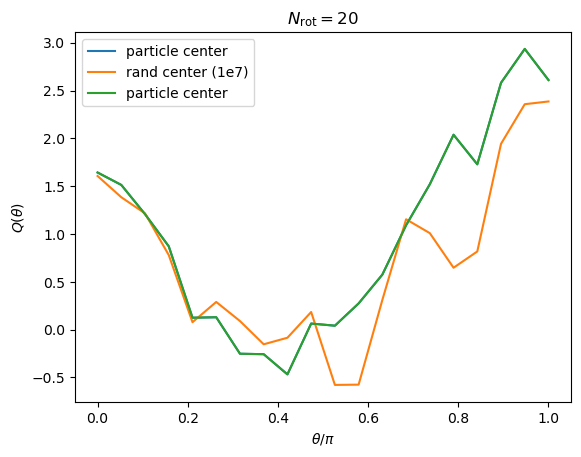

In [20]:
plt.plot(corr3pcf_data_part.theta/np.pi, corr3pcf_data_part.Q, label='particle center')
plt.plot(corr3pcf_data_rand.theta/np.pi, corr3pcf_data_rand.Q, label='rand center (1e7)')

plt.plot(theta_values/np.pi, Q1_theta, label='particle center')
# plt.plot(theta_values/np.pi, Q2_theta, label='random center (1e7)')
plt.legend()
plt.title(r'$N_{\rm rot}=20$')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta)$")
plt.show()